### ディフェンシブ銘柄のラベル付け

In [20]:
# ============================================================
# #(1) import / 定数
# ============================================================
import os
import pandas as pd

IDMAP_CSV = os.path.join("Data", "01_IDmap.csv")
DEF_LABEL = "L_def"


# ============================================================
# #(2) IDmap 読み込み・保存（他列不変更）
# ============================================================
def _load_idmap_df() -> pd.DataFrame:
    df = pd.read_csv(IDMAP_CSV, dtype={"code": "string"}, encoding="utf-8-sig")

    # BOM付き code 列対策（列名だけ補正。データ内容は一切編集しない）
    if "code" not in df.columns:
        for c in df.columns:
            if str(c).replace("\ufeff", "") == "code":
                df = df.rename(columns={c: "code"})
                break

    if "code" not in df.columns:
        raise ValueError("01_IDmap.csv に 'code' 列が見つかりません。")

    # L_def が無ければ列だけ追加（他列は触らない）
    if DEF_LABEL not in df.columns:
        df[DEF_LABEL] = pd.NA

    return df


def _save_idmap_df(df: pd.DataFrame) -> None:
    # 元の列構成を維持したまま保存（編集はL_def列の中身のみ）
    df.to_csv(IDMAP_CSV, index=False, encoding="utf-8-sig")


# ============================================================
# #(3) code 正規化（照合用：元データは変更しない）
#   - 数字だけなら 4桁はゼロ埋め（"1"→"0001"）
#   - 5桁以上(例: 94345 等)はそのまま
# ============================================================
def _normalize_code_for_match(x) -> str:
    if pd.isna(x):
        return ""
    s = str(x).strip()
    if s.isdigit():
        return s.zfill(4) if len(s) <= 4 else s
    return s


def _normalize_codes_list(codes) -> list[str]:
    if codes is None:
        return []
    if isinstance(codes, (str, int)):
        codes = [codes]
    return [_normalize_code_for_match(c) for c in codes]


# ============================================================
# #(4) ラベル付与本体（L_def以外は一切触らない）
#   仕様：
#     defensive_codes → L_def=1
#     offensive_codes → L_def=0
#     その他 → L_def=空欄
# ============================================================
def set_def_labels(defensive_codes=None, offensive_codes=None, *, verbose=True) -> pd.DataFrame:
    df = _load_idmap_df()

    def_list = _normalize_codes_list(defensive_codes)
    off_list = _normalize_codes_list(offensive_codes)

    # 競合チェック（同一銘柄が両方に入っていたら defensive を優先）
    overlap = sorted(set(def_list) & set(off_list))
    if overlap and verbose:
        print(f"[WARN] defensive と offensive に重複があるため defensive(=1) を優先します: {overlap}")

    # 照合用の正規化コード（df自体の code は変更しない）
    code_norm = df["code"].map(_normalize_code_for_match)

    # まず L_def を全行クリア（= その他は空欄）
    df[DEF_LABEL] = pd.NA

    # defensive を 1
    if def_list:
        df.loc[code_norm.isin(def_list), DEF_LABEL] = 1

    # offensive を 0（ただし重複分は defensive 優先のため除外）
    off_only = [c for c in off_list if c not in set(def_list)]
    if off_only:
        df.loc[code_norm.isin(off_only), DEF_LABEL] = 0

    _save_idmap_df(df)

    # レポート（指定分が見つかったか）
    requested = sorted(set(def_list + off_list))
    found_set = set(code_norm[code_norm.isin(requested)].tolist())
    missing = [c for c in requested if c not in found_set]

    if verbose:
        print(f"[OK] L_def 更新完了: defensive={len(def_list)} offensive={len(off_list)} / total_rows={len(df)}")
        if missing:
            print(f"[WARN] 01_IDmap.csv に見つからなかった code: {missing}")

    # 返り値：指定銘柄の現状（見つかったものだけ）
    report = df.loc[code_norm.isin(requested), ["code", DEF_LABEL]].copy()
    report = report.sort_values("code")
    return report


def defensive(codes, *, verbose=True) -> pd.DataFrame:
    """
    指定銘柄を defensive(=1) にし、それ以外は空欄にします。
    """
    return set_def_labels(defensive_codes=codes, offensive_codes=[], verbose=verbose)


def offensive(codes, *, verbose=True) -> pd.DataFrame:
    """
    指定銘柄を offensive(=0) にし、それ以外は空欄にします。
    """
    return set_def_labels(defensive_codes=[], offensive_codes=codes, verbose=verbose)


# defensiveだけ指定（他は全部空欄）
defensive_codes=[
    "1723", "1951", "1976", "2003", "2169", "2185", "2269", "2317",
    "2374", "2391", "2659", "3333", "3771", "3834", "4540", "4719",
    "4743", "6458", "6745", "7292", "7438", "7483", "7723",
    "7749", "7817", "7921", "7994", "9057", "9069", "9303", "9364",
    "9368", "9381", "9687", "9769", "9795",
]

offensive_codes=[
    "1414", "1928", "1980", "3076", "3231", "3817", "4008", "4041",
    "4042", "4097", "4220", "4345", "4401", "4641", "4748", "4752",
    "4832", "4972", "5011", "5186", "5388", "5464", "6322", "6345", "6381",
    "6432", "6454", "6652", "6785", "6957", "7820", "7931", "7989",
    "8130", "9233", "9304", "9882", "9960", "9986",
]

# defensive/offensiveを同時に確定（おすすめ）
set_def_labels(defensive_codes=defensive_codes, offensive_codes=offensive_codes)

[OK] L_def 更新完了: defensive=36 offensive=39 / total_rows=4426
[WARN] 01_IDmap.csv に見つからなかった code: ['4748']


,code,L_def
345,1414,0
503,1723,1
577,1928,0
591,1951,1
605,1976,1
...,...,...
4327,9769,1
4336,9795,1
4368,9882,0
4398,9960,0


### L_高配当にラベルがついていて、L_defにラベルが入っていない銘柄の抽出

In [21]:
# ============================================================
# #(1) L_高配当 & L_def未ラベル銘柄 抽出（セル単体で完結）
#   - 入力: Data/01_IDmap.csv
#   - 条件: L_高配当 == 1 かつ L_def が 0/1 ではない（空欄/NaN/未記入など）
#   - 出力:
#       pending_def_df : 抽出DF（後で判定結果を書き込む対象）
#       pending_codes  : code リスト
# ============================================================

import pandas as pd
import numpy as np

def extract_pending_def_labels(
    idmap_path: str = "Data/01_IDmap.csv",
    code_col: str = "code",
    high_div_col: str = "L_高配当",
    def_col: str = "L_def",
    name_col_candidates=("name", "銘柄名", "名称"),
    industry_col_candidates=("industry_33", "業種", "業種33"),
    verbose: bool = True,
):
    # ---- read (BOM対策含む) ----
    df = pd.read_csv(idmap_path, dtype="string", encoding="utf-8-sig")

    # 列名のBOMや空白を軽く正規化
    df.columns = [str(c).replace("\ufeff", "").strip() for c in df.columns]

    # 必須列チェック
    required = {code_col, high_div_col, def_col}
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"01_IDmap.csv に必要列が見つかりません: {missing}\n現在の列: {list(df.columns)}")

    # name / industry は存在すれば表示用に拾う（無ければOK）
    name_col = next((c for c in name_col_candidates if c in df.columns), None)
    industry_col = next((c for c in industry_col_candidates if c in df.columns), None)

    # ---- values normalize ----
    # code: 文字列トリム
    df[code_col] = df[code_col].astype("string").str.strip()

    # L_高配当: 1判定（"1", "1.0", 1 などを許容）
    high = pd.to_numeric(df[high_div_col], errors="coerce").fillna(0).astype(int)

    # L_def: 0/1 が入っているものだけ「ラベル済み」とみなす
    # 空欄/NaN/その他文字 は未記入扱い
    def_num = pd.to_numeric(df[def_col], errors="coerce")  # NaNになれば未記入候補
    labeled = def_num.isin([0, 1])

    pending_mask = (high == 1) & (~labeled)

    # ---- build output df ----
    cols = [code_col]
    if name_col:
        cols.append(name_col)
    if industry_col:
        cols.append(industry_col)
    cols += [high_div_col, def_col]

    pending_def_df = df.loc[pending_mask, cols].copy()

    # 表示用に並び替え（code昇順）
    pending_def_df = pending_def_df.sort_values(code_col).reset_index(drop=True)

    pending_codes = pending_def_df[code_col].dropna().astype("string").tolist()

    if verbose:
        print(f"[PENDING] 抽出件数: {len(pending_codes)}")
        if len(pending_codes) > 0:
            print(f"[PENDING] 先頭10件: {pending_codes[:10]}")
        else:
            print("[PENDING] 該当なし（L_高配当==1 かつ L_def未記入 は0件）")

    return pending_def_df, pending_codes


# ------------------------------------------------------------
# #(2) 実行
# ------------------------------------------------------------
pending_def_df, pending_codes = extract_pending_def_labels(verbose=True)

# ------------------------------------------------------------
# #(3) 後続ロジック追加用の“作業対象DF”として保持
#     例: pending_def_df に判定結果列を追加していく想定
# ------------------------------------------------------------
# pending_def_df["def_judge"] = ""  # "defensive"/"offensive" など
# pending_def_df["judge_reason"] = ""  # 判定理由メモ
pending_def_df

[PENDING] 抽出件数: 55
[PENDING] 先頭10件: ['1343', '1488', '1489', '1835', '2124', '2296', '2353', '2393', '2556', '2558']


,code,name,industry_33,L_高配当,L_def
0,1343,ＮＥＸＴ ＦＵＮＤＳ 東証ＲＥＩＴ指数連動型上場投信,J-REIT,1,<NA>
1,1488,ｉＦｒｅｅＥＴＦ 東証ＲＥＩＴ指数,J-REIT,1,<NA>
2,1489,0,-,1,<NA>
3,1835,東鉄工業,建設業,1,<NA>
4,2124,ジェイエイシーリクルートメント,サービス業,1,<NA>
5,2296,伊藤ハム米久 HD,食料品,1,<NA>
6,2353,日本駐車場開発,不動産業,1,<NA>
7,2393,日本ケアサプライ,サービス業,1,<NA>
8,2556,Ｏｎｅ ＥＴＦ 東証ＲＥＩＴ指数,J-REIT,1,<NA>
9,2558,ＭＸＳ米株ＳＰ５００,米国ETF,1,<NA>


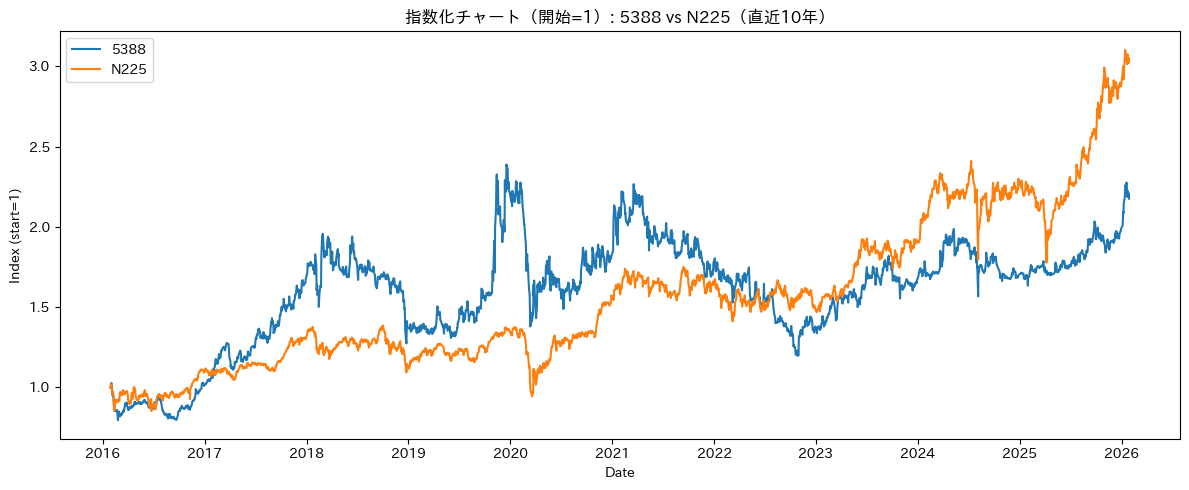

,5388,N225
date,,
2016-01-29,1.0,1.0
2016-02-01,1.026756,1.019804
2016-02-02,1.026756,1.013265
2016-02-03,1.003344,0.981331
2016-02-04,0.989967,0.972982
...,...,...
2026-01-22,2.185619,3.064732
2026-01-23,2.22408,3.07375
2026-01-26,2.198997,3.018857


In [22]:
# ============================================================
# #(1) 1銘柄コードの株価チャート vs 日経平均（N225）を「同一グラフ」に重ね描き（指数化）
#   - 直近10年（デフォルト）
#   - 指数化：期間先頭日の値を 1.0 として正規化
#   - 株価データ: Data/kabuka/YYYY.csv（N225列あり）
#
# 使い方:
#   chk("1343")            # 直近10年（指数化して重ね描き）
#   chk("1343", years=5)   # 期間変更も可能
# ============================================================

import os
import glob
import re
import pandas as pd
import matplotlib.pyplot as plt
import japanize_matplotlib
from dateutil.relativedelta import relativedelta

def _load_kabuka_range(start_date: pd.Timestamp, end_date: pd.Timestamp, kabuka_dir="Data/kabuka") -> pd.DataFrame:
    paths = sorted(glob.glob(os.path.join(kabuka_dir, "*.csv")))
    if not paths:
        raise FileNotFoundError(f"kabuka CSVが見つかりません: {kabuka_dir}")

    years = []
    for p in paths:
        m = re.search(r"(\d{4})\.csv$", os.path.basename(p))
        if m:
            years.append((int(m.group(1)), p))
    if not years:
        raise FileNotFoundError(f"kabuka CSVのファイル名が YYYY.csv 形式ではありません: {kabuka_dir}")

    y_from = int(start_date.year)
    y_to   = int(end_date.year)
    target_paths = [p for y, p in years if y_from <= y <= y_to]
    if not target_paths:
        raise FileNotFoundError(f"{y_from}〜{y_to}年に該当する kabuka CSV がありません。")

    dfs = []
    for p in sorted(target_paths):
        df = pd.read_csv(p, dtype="string", encoding="utf-8-sig")
        df.columns = [str(c).replace("\ufeff", "").strip() for c in df.columns]
        first_col = df.columns[0]
        df = df.rename(columns={first_col: "date"})

        df["date"] = df["date"].astype("string").str.strip()
        df = df[df["date"].str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)].copy()
        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"]).set_index("date")

        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

        dfs.append(df)

    all_df = pd.concat(dfs, axis=0).sort_index()
    all_df = all_df.loc[(all_df.index >= start_date) & (all_df.index <= end_date)]
    return all_df

def _get_latest_kabuka_day(kabuka_dir="Data/kabuka") -> pd.Timestamp:
    paths = sorted(glob.glob(os.path.join(kabuka_dir, "*.csv")))
    if not paths:
        raise FileNotFoundError(f"kabuka CSVが見つかりません: {kabuka_dir}")

    years = []
    for p in paths:
        m = re.search(r"(\d{4})\.csv$", os.path.basename(p))
        if m:
            years.append((int(m.group(1)), p))
    if not years:
        raise FileNotFoundError(f"kabuka CSVのファイル名が YYYY.csv 形式ではありません: {kabuka_dir}")

    latest_path = sorted(years, key=lambda x: x[0])[-1][1]
    df = pd.read_csv(latest_path, dtype="string", encoding="utf-8-sig")
    df.columns = [str(c).replace("\ufeff", "").strip() for c in df.columns]
    first_col = df.columns[0]
    df = df.rename(columns={first_col: "date"})

    df["date"] = df["date"].astype("string").str.strip()
    df = df[df["date"].str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)].copy()
    if df.empty:
        raise ValueError(f"最新ファイルに日付行がありません: {latest_path}")

    last_day = pd.to_datetime(df["date"].iloc[-1], errors="coerce")
    if pd.isna(last_day):
        raise ValueError(f"最終日のパースに失敗しました: {latest_path}")
    return last_day

def chk(code: str, years: int = 10, kabuka_dir: str = "Data/kabuka", n225_col: str = "N225"):
    """
    指定codeの直近years年の株価とN225を、指数化して同一グラフに重ね描き
    指数化: 各系列の期間先頭の有効値を 1.0 にする
    """
    code = str(code).strip()

    last_day = _get_latest_kabuka_day(kabuka_dir=kabuka_dir)
    start_day = (last_day - relativedelta(years=years))

    df = _load_kabuka_range(start_day, last_day, kabuka_dir=kabuka_dir)

    available = set(df.columns.astype(str))
    if n225_col not in available:
        raise KeyError(f"N225列({n225_col})が見つかりません。利用可能列の例: {list(df.columns[:10])}")
    if code not in available:
        raise KeyError(f"銘柄コード列({code})が見つかりません。利用可能列の例: {list(df.columns[:10])}")

    pair = df[[code, n225_col]].copy()

    # 2系列とも、同じ日付で揃えて比較する（両方値がある日だけ）
    pair = pair.dropna(how="any")
    if pair.empty or len(pair) < 2:
        raise ValueError(f"比較可能なデータが不足しています（{code} と {n225_col} の同日データがありません）。")

    # 指数化（先頭を1.0）
    base = pair.iloc[0]
    idx = pair / base

    # 描画（重ね描き）
    plt.figure(figsize=(12, 5))
    plt.plot(idx.index, idx[code].values, label=code)
    plt.plot(idx.index, idx[n225_col].values, label=n225_col)

    plt.title(f"指数化チャート（開始=1）: {code} vs {n225_col}（直近{years}年）")
    plt.xlabel("Date")
    plt.ylabel("Index (start=1)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 後続分析用に返す（指数化後）
    return idx

# --- 実行例 ---
chk("5388")

### ディフェンシブ指標のスコア化

[INFO] 対象（L_高配当==1）件数: 125
L_def_group
L_def=空欄    55
L_def=0     37
L_def=1     33
Name: count, dtype: int64


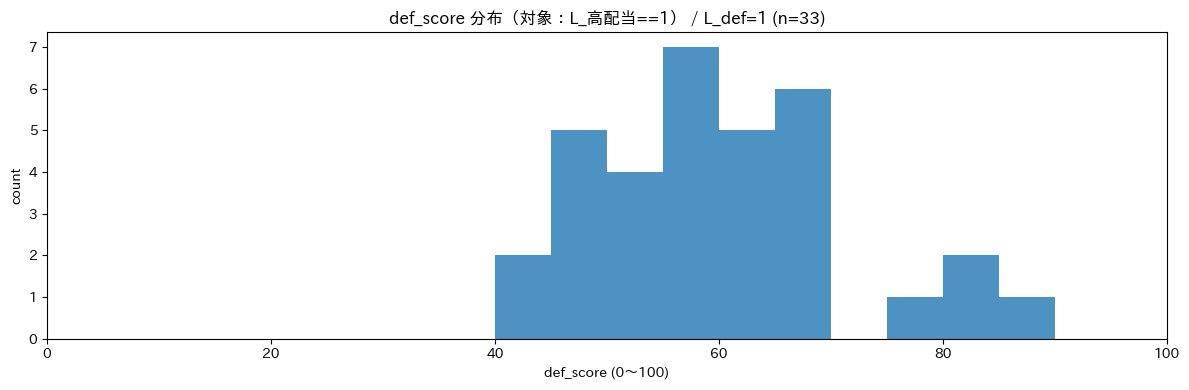

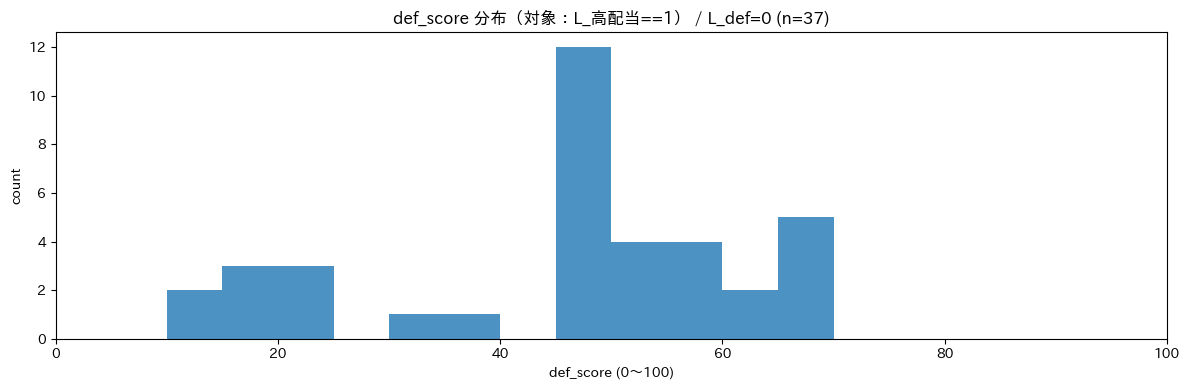

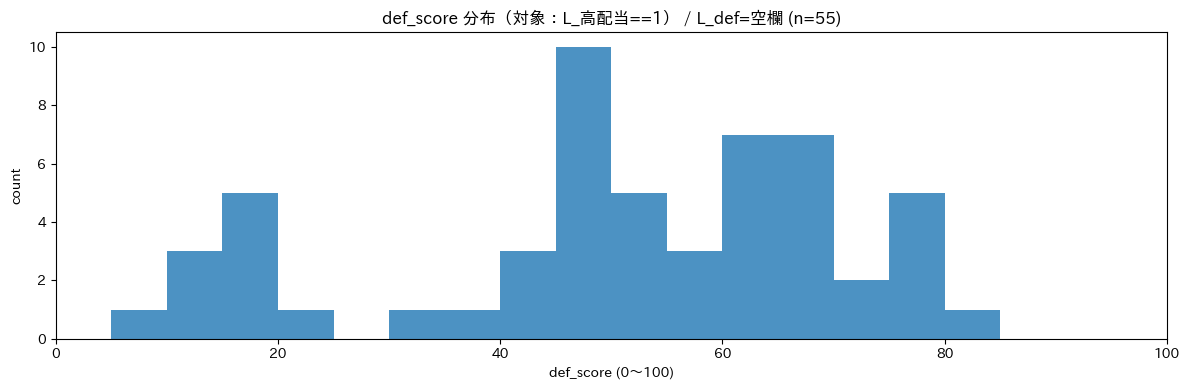

,code,name,industry_33,L_def,L_def_group,def_score,score_downcorr,score_vol,score_mdd,corr_down,vol_ratio,mdd_ratio,n_months,n_down_months
0,2391,プラネット,サービス業,1,L_def=1,86.000000,100.000000,100.000000,30.0,0.122023,0.869292,1.854307,120,46
1,9432,NTT,情報・通信業,<NA>,L_def=空欄,83.410310,95.610997,98.682706,30.0,0.226334,0.907904,1.245089,120,46
2,2003,日東富士製粉,食料品,1,L_def=1,83.308842,87.803059,64.691042,100.0,0.273182,1.111854,0.654380,120,46
3,7749,メディキット,精密機器,1,L_def=1,80.713458,91.252765,96.956916,30.0,0.252483,0.918259,1.854307,120,46
4,9433,KDDI,情報・通信業,<NA>,L_def=空欄,79.012082,100.000000,76.706940,30.0,0.128900,1.039758,1.220165,120,46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120,7995,バルカー,化学,<NA>,L_def=空欄,13.844289,34.610722,0.000000,0.0,0.592336,1.693441,1.854307,120,46
121,5334,日本特殊陶業,ガラス・土石製品,<NA>,L_def=空欄,13.078685,32.696712,0.000000,0.0,0.603820,1.910344,1.854307,120,46
122,6539,MS-Japan,サービス業,<NA>,L_def=空欄,11.335246,28.338116,0.000000,0.0,0.629971,2.375585,1.854307,109,42
123,6432,竹内製作所,機械,0,L_def=0,11.320131,28.300327,0.000000,0.0,0.630198,2.231394,1.854307,120,46


In [23]:
# ============================================================
# #(1) def_score（②〜④のみ）を0〜100で作成し、L_def(0/1/空欄)別に分布を可視化
#   ② 下落局面相関（N225がマイナスの月だけの相関） …低いほど良い
#   ③ ボラ比（銘柄vol / N225vol） …低いほど良い
#   ④ MDD比（|MDD_stock| / |MDD_n225|） …低いほど良い
#
#   - 対象銘柄: Data/01_IDmap.csv の L_高配当==1 の銘柄
#   - 株価: Data/kabuka/YYYY.csv（列に銘柄コードと N225 がある）
#   - 出力:
#       df_vis : code, def_score, L_def 等を含むDF
#       ヒストグラム（横軸 def_score、色= L_def=1/0/空欄）
# ============================================================

import os, glob, re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dateutil.relativedelta import relativedelta

IDMAP_PATH = "Data/01_IDmap.csv"
KABUKA_DIR = "Data/kabuka"
N225_COL   = "N225"

# ----------------------------
# #(2) kabuka読み込み（10年分）
# ----------------------------
def _get_latest_kabuka_day(kabuka_dir=KABUKA_DIR) -> pd.Timestamp:
    paths = sorted(glob.glob(os.path.join(kabuka_dir, "*.csv")))
    if not paths:
        raise FileNotFoundError(f"kabuka CSVが見つかりません: {kabuka_dir}")

    years = []
    for p in paths:
        m = re.search(r"(\d{4})\.csv$", os.path.basename(p))
        if m:
            years.append((int(m.group(1)), p))
    if not years:
        raise FileNotFoundError(f"kabuka CSVのファイル名が YYYY.csv 形式ではありません: {kabuka_dir}")

    latest_path = sorted(years, key=lambda x: x[0])[-1][1]
    df = pd.read_csv(latest_path, dtype="string", encoding="utf-8-sig")
    df.columns = [str(c).replace("\ufeff", "").strip() for c in df.columns]
    first_col = df.columns[0]
    df = df.rename(columns={first_col: "date"})

    df["date"] = df["date"].astype("string").str.strip()
    df = df[df["date"].str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)].copy()
    if df.empty:
        raise ValueError(f"最新ファイルに日付行がありません: {latest_path}")

    last_day = pd.to_datetime(df["date"].iloc[-1], errors="coerce")
    if pd.isna(last_day):
        raise ValueError(f"最終日のパースに失敗しました: {latest_path}")
    return last_day

def _load_kabuka_range(start_date: pd.Timestamp, end_date: pd.Timestamp, kabuka_dir=KABUKA_DIR) -> pd.DataFrame:
    paths = sorted(glob.glob(os.path.join(kabuka_dir, "*.csv")))
    if not paths:
        raise FileNotFoundError(f"kabuka CSVが見つかりません: {kabuka_dir}")

    years = []
    for p in paths:
        m = re.search(r"(\d{4})\.csv$", os.path.basename(p))
        if m:
            years.append((int(m.group(1)), p))
    if not years:
        raise FileNotFoundError(f"kabuka CSVのファイル名が YYYY.csv 形式ではありません: {kabuka_dir}")

    y_from, y_to = int(start_date.year), int(end_date.year)
    target_paths = [p for y, p in years if y_from <= y <= y_to]
    if not target_paths:
        raise FileNotFoundError(f"{y_from}〜{y_to}年に該当する kabuka CSV がありません。")

    dfs = []
    for p in sorted(target_paths):
        df = pd.read_csv(p, dtype="string", encoding="utf-8-sig")
        df.columns = [str(c).replace("\ufeff", "").strip() for c in df.columns]
        first_col = df.columns[0]
        df = df.rename(columns={first_col: "date"})

        # name行を除外し、日付行だけ
        df["date"] = df["date"].astype("string").str.strip()
        df = df[df["date"].str.match(r"^\d{4}-\d{2}-\d{2}$", na=False)].copy()

        df["date"] = pd.to_datetime(df["date"], errors="coerce")
        df = df.dropna(subset=["date"]).set_index("date")

        for c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

        dfs.append(df)

    all_df = pd.concat(dfs, axis=0).sort_index()
    all_df = all_df.loc[(all_df.index >= start_date) & (all_df.index <= end_date)]
    return all_df

# ----------------------------
# #(3) 指標計算（②〜④）
# ----------------------------
def _monthly_returns(price_s: pd.Series) -> pd.Series:
    """日次終値 -> 月末終値 -> 月次リターン（単純）"""
    m = price_s.dropna().resample("M").last()
    r = m.pct_change(fill_method=None)
    return r.dropna()


def _max_drawdown(indexed_price: pd.Series) -> float:
    """指数化済み価格系列（開始=1など）から最大ドローダウン（負の値）"""
    s = indexed_price.dropna()
    if s.empty:
        return np.nan
    peak = s.cummax()
    dd = (s / peak) - 1.0
    return float(dd.min())

def _score_low_better(x, good, bad) -> float:
    """
    x: 値（低いほど良い）
    good: これ以下は100点
    bad:  これ以上は0点
    good〜badは線形
    """
    if pd.isna(x):
        return np.nan
    if x <= good:
        return 100.0
    if x >= bad:
        return 0.0
    return float(100.0 * (bad - x) / (bad - good))

def _safe_corr(a: pd.Series, b: pd.Series) -> float:
    df = pd.concat([a, b], axis=1).dropna()
    if len(df) < 12:  # 月次で最低1年分くらい欲しい
        return np.nan
    return float(df.iloc[:, 0].corr(df.iloc[:, 1]))

def calc_def_score_for_code(
    price_df: pd.DataFrame,
    code: str,
    n225_col: str = N225_COL,
    w_downcorr=0.4,
    w_vol=0.3,
    w_mdd=0.3,
    # --- 改善①：MDDクリップ（下限） ---
    mdd_clip: float = -0.40,   # 例：-40%より深い下落は一律 -40% 扱い
    # --- 改善②：volレンジ緩和 ---
    vol_good: float = 0.9,     # これ以下は100点
    vol_bad: float  = 1.5,     # これ以上は0点
    # --- 改善③：条件付きでMDD重みを下げる ---
    downcorr_strong_th: float = 50.0,  # score_downcorr がこの点以上なら「下げ耐性が強い」とみなす
    w_mdd_when_strong: float = 0.2,    # 強いときのMDD重み
    # --- 改善④：救済ルール（ver3） ---
    rescue_floor: float = 30.0,         # 下げ耐性が強い銘柄の score_vol / score_mdd の最低点
):
    """
    ②〜④を0〜100に正規化して def_score を作る（改善①〜④反映版）
    返り値: dict
    """
    code = str(code).strip()
    if code not in price_df.columns:
        return None
    if n225_col not in price_df.columns:
        raise KeyError(f"{n225_col} 列が kabuka に見つかりません。")

    s_stock = price_df[code].dropna()
    s_n225  = price_df[n225_col].dropna()

    # 月次リターン
    r_stock = _monthly_returns(s_stock)
    r_n225  = _monthly_returns(s_n225)

    # 日付合わせ
    r_pair = pd.concat([r_stock.rename("stock"), r_n225.rename("n225")], axis=1).dropna()
    if len(r_pair) < 24:  # 2年未満は判定がブレやすいので除外
        return {
            "code": code,
            "def_score": np.nan,
            "score_downcorr": np.nan,
            "score_vol": np.nan,
            "score_mdd": np.nan,
            "corr_down": np.nan,
            "vol_ratio": np.nan,
            "mdd_ratio": np.nan,
            "n_months": int(len(r_pair)),
        }

    # ② 下落局面相関（N225<0の月だけ）
    down = r_pair[r_pair["n225"] < 0]
    corr_down = _safe_corr(down["stock"], down["n225"])
    score_down = _score_low_better(corr_down, good=0.2, bad=0.8)

    # ③ ボラ比（標準偏差）  ※改善②：レンジ緩和
    vol_stock = float(r_pair["stock"].std(ddof=0))
    vol_n225  = float(r_pair["n225"].std(ddof=0))
    vol_ratio = (vol_stock / vol_n225) if (vol_n225 and not np.isnan(vol_n225)) else np.nan
    score_vol = _score_low_better(vol_ratio, good=vol_good, bad=vol_bad)

    # ④ MDD比（指数化した価格で最大下落率）
    # 月末終値で比較（ノイズ減）
    m_stock = s_stock.resample("M").last().dropna()
    m_n225  = s_n225.resample("M").last().dropna()
    m_pair_price = pd.concat([m_stock.rename("stock"), m_n225.rename("n225")], axis=1).dropna()

    if len(m_pair_price) < 24:
        mdd_ratio = np.nan
        score_mdd = np.nan
        mdd_stock = np.nan
        mdd_n225  = np.nan
    else:
        idx = m_pair_price / m_pair_price.iloc[0]  # 開始=1
        mdd_stock = _max_drawdown(idx["stock"])
        mdd_n225  = _max_drawdown(idx["n225"])

        # --- 改善①：MDDクリップ（深すぎる下落を一律に丸める） ---
        if not pd.isna(mdd_stock):
            mdd_stock = max(float(mdd_stock), float(mdd_clip))
        if not pd.isna(mdd_n225):
            mdd_n225  = max(float(mdd_n225),  float(mdd_clip))

        if pd.isna(mdd_stock) or pd.isna(mdd_n225) or (abs(mdd_n225) < 1e-12):
            mdd_ratio = np.nan
            score_mdd = np.nan
        else:
            mdd_ratio = abs(mdd_stock) / abs(mdd_n225)
            score_mdd = _score_low_better(mdd_ratio, good=0.8, bad=1.2)

    # NaN補完（指標が取れない場合は中立50点に寄せる）
    def _neutral(x):
        return 50.0 if pd.isna(x) else float(x)

    score_down_n = _neutral(score_down)
    score_vol_n  = _neutral(score_vol)
    score_mdd_n  = _neutral(score_mdd)

    # --- 改善④：救済ルール（ver3）
    # 下げ耐性（②）が強いなら、「荒さ（③④）」で0点になっても最低限は救う
    if score_down_n >= float(downcorr_strong_th):
        score_vol_n = max(score_vol_n, float(rescue_floor))
        score_mdd_n = max(score_mdd_n, float(rescue_floor))

    # --- 改善③：下げ耐性が強い銘柄は MDD の重みを下げる ---
    w_down_eff, w_vol_eff, w_mdd_eff = float(w_downcorr), float(w_vol), float(w_mdd)
    if score_down_n >= float(downcorr_strong_th):
        w_mdd_eff = float(w_mdd_when_strong)
        # 減らした分を下落相関側へ寄せる（合計1.0を維持）
        delta = float(w_mdd) - w_mdd_eff
        w_down_eff = float(w_downcorr) + delta

    # 念のため合計がズレないように正規化
    w_sum = w_down_eff + w_vol_eff + w_mdd_eff
    if w_sum > 0:
        w_down_eff /= w_sum
        w_vol_eff  /= w_sum
        w_mdd_eff  /= w_sum

    def_score = (w_down_eff * score_down_n) + (w_vol_eff * score_vol_n) + (w_mdd_eff * score_mdd_n)

    return {
        "code": code,
        "def_score": float(def_score),
        "score_downcorr": float(score_down_n),
        "score_vol": float(score_vol_n),
        "score_mdd": float(score_mdd_n),
        "corr_down": (np.nan if pd.isna(corr_down) else float(corr_down)),
        "vol_ratio": (np.nan if pd.isna(vol_ratio) else float(vol_ratio)),
        "mdd_ratio": (np.nan if pd.isna(mdd_ratio) else float(mdd_ratio)),
        "mdd_stock": (np.nan if pd.isna(mdd_stock) else float(mdd_stock)),
        "mdd_n225":  (np.nan if pd.isna(mdd_n225)  else float(mdd_n225)),
        "n_months": int(len(r_pair)),
        "n_down_months": int(len(down)),
        "w_down_eff": float(w_down_eff),
        "w_vol_eff":  float(w_vol_eff),
        "w_mdd_eff":  float(w_mdd_eff),
        "rescue_floor": float(rescue_floor),
    }

# ----------------------------
# #(4) IDmap読込 → L_高配当銘柄だけ抽出 → def_score算出
# ----------------------------
idmap = pd.read_csv(IDMAP_PATH, dtype="string", encoding="utf-8-sig")
idmap.columns = [str(c).replace("\ufeff", "").strip() for c in idmap.columns]

for c in ["code", "L_高配当", "L_def"]:
    if c not in idmap.columns:
        raise KeyError(f"{IDMAP_PATH} に列 {c} がありません。現在の列: {list(idmap.columns)}")

idmap["code"] = idmap["code"].astype("string").str.strip()
high = pd.to_numeric(idmap["L_高配当"], errors="coerce").fillna(0).astype(int)
high_df = idmap.loc[high == 1, ["code", "L_def"]].copy()

# kabuka 10年分ロード
last_day = _get_latest_kabuka_day(KABUKA_DIR)
start_day = last_day - relativedelta(years=10)
price_df = _load_kabuka_range(start_day, last_day, KABUKA_DIR)

# スコア計算
rows = []
for code in high_df["code"].dropna().unique().tolist():
    r = calc_def_score_for_code(price_df, code, n225_col=N225_COL)
    if r is not None:
        rows.append(r)

score_df = pd.DataFrame(rows)

# 可視化用DF（L_defを結合）
df_vis = high_df.merge(score_df, on="code", how="left")

# L_def の分類（0/1/空欄） ※pd.NA安全版（np.whereを使わない）
def_num = pd.to_numeric(df_vis["L_def"], errors="coerce")
df_vis["L_def_group"] = "L_def=空欄"
df_vis.loc[def_num == 1, "L_def_group"] = "L_def=1"
df_vis.loc[def_num == 0, "L_def_group"] = "L_def=0"

print("[INFO] 対象（L_高配当==1）件数:", len(df_vis))
print(df_vis["L_def_group"].value_counts(dropna=False))

# ----------------------------
# #(5) 分布を可視化（横軸 def_score / L_def=1,0,空欄 を別グラフで表示）
#     ＋ def_score降順の一覧表を表示（name / industry_33 結合）
# ----------------------------
bins = np.linspace(0, 100, 21)  # 0〜100を20分割
groups = ["L_def=1", "L_def=0", "L_def=空欄"]

for grp in groups:
    s = df_vis.loc[df_vis["L_def_group"] == grp, "def_score"].dropna()
    plt.figure(figsize=(12, 4))
    plt.hist(s, bins=bins, alpha=0.8)
    plt.title(f"def_score 分布（対象：L_高配当==1） / {grp} (n={len(s)})")
    plt.xlabel("def_score (0〜100)")
    plt.ylabel("count")
    plt.xlim(0, 100)
    plt.tight_layout()
    plt.show()

# --- 一覧表（def_score 降順） ---
# 01_IDmap.csv から name / industry_33 を付与（存在する列だけ）
name_col = "name" if "name" in idmap.columns else None
industry_col = "industry_33" if "industry_33" in idmap.columns else None

meta_cols = ["code"]
if name_col:
    meta_cols.append(name_col)
if industry_col:
    meta_cols.append(industry_col)

meta_df = idmap.loc[:, meta_cols].copy()
meta_df["code"] = meta_df["code"].astype("string").str.strip()
meta_df = meta_df.drop_duplicates(subset=["code"])

# df_vis に結合（重複防止のため left）
df_table_base = df_vis.merge(meta_df, on="code", how="left")

# 見やすい列だけに絞る（存在する列だけ採用）
preferred_cols = [
    "code",
    name_col,
    industry_col,
    "L_def", "L_def_group",
    "def_score", "score_downcorr", "score_vol", "score_mdd",
    "corr_down", "vol_ratio", "mdd_ratio",
    "n_months", "n_down_months"
]
preferred_cols = [c for c in preferred_cols if c is not None]
cols = [c for c in preferred_cols if c in df_table_base.columns]

df_table = df_table_base.loc[:, cols].copy()

# def_score の降順（NaNは最後へ）
df_table = df_table.sort_values(by="def_score", ascending=False, na_position="last").reset_index(drop=True)

df_table

In [24]:
# ============================================================
# #(6) レビュー用：
#   L_def=1 なのに def_score が低い銘柄 TOP5 を抽出
#   （内訳も一緒に確認）
# ============================================================

# 閾値（ここは調整可）
LOW_SCORE_TH = 40
TOPN = 5

# L_def=1 かつ def_score が低い銘柄
df_mismatch = df_vis.loc[
    (df_vis["L_def_group"] == "L_def=1") &
    (df_vis["def_score"].notna()) &
    (df_vis["def_score"] < LOW_SCORE_TH)
].copy()

print(f"[INFO] L_def=1 & def_score<{LOW_SCORE_TH} 件数:", len(df_mismatch))

# def_score 昇順（＝一番ズレている順）
df_mismatch = df_mismatch.sort_values("def_score", ascending=True).head(TOPN)

# 表示用カラム（存在するものだけ）
preferred_cols = [
    "code",
    "name",            # あれば表示
    "industry_33",     # あれば表示
    "def_score",
    "score_downcorr",
    "score_vol",
    "score_mdd",
    "corr_down",
    "vol_ratio",
    "mdd_ratio",
    "n_months",
    "n_down_months",
]

cols = [c for c in preferred_cols if c in df_mismatch.columns]

df_mismatch.loc[:, cols].reset_index(drop=True)


[INFO] L_def=1 & def_score<40 件数: 0


,code,def_score,score_downcorr,score_vol,score_mdd,corr_down,vol_ratio,mdd_ratio,n_months,n_down_months


In [26]:
# ============================================================
# #(7) レビュー用：
#   L_def=0 なのに def_score が高い銘柄 TOP5 を抽出（内訳も確認）
# ============================================================

HIGH_SCORE_TH = 60   # 「高い」の閾値（必要なら 60〜80 で調整）
TOPN = 5

df_mismatch2 = df_vis.loc[
    (df_vis["L_def_group"] == "L_def=0") &
    (df_vis["def_score"].notna()) &
    (df_vis["def_score"] >= HIGH_SCORE_TH)
].copy()

print(f"[INFO] L_def=0 & def_score>={HIGH_SCORE_TH} 件数:", len(df_mismatch2))

df_mismatch2 = df_mismatch2.sort_values("def_score", ascending=False).head(TOPN)

preferred_cols = [
    "code",
    "name", "industry_33",
    "def_score",
    "score_downcorr", "score_vol", "score_mdd",
    "corr_down", "vol_ratio", "mdd_ratio",
    "n_months", "n_down_months",
]
cols = [c for c in preferred_cols if c in df_mismatch2.columns]

df_mismatch2.loc[:, cols].reset_index(drop=True)


[INFO] L_def=0 & def_score>=60 件数: 7


,code,def_score,score_downcorr,score_vol,score_mdd,corr_down,vol_ratio,mdd_ratio,n_months,n_down_months
0,9986,69.986147,67.972293,100.0,30.0,0.392166,0.874307,1.729489,120,46
1,1980,65.000000,100.000000,30.0,30.0,0.120771,1.692224,1.554302,120,46
2,7931,65.000000,100.000000,30.0,30.0,0.181082,1.723604,1.996504,85,33
3,7989,65.000000,100.000000,30.0,30.0,0.186344,1.361867,1.798258,120,46
4,9304,65.000000,100.000000,30.0,30.0,0.078164,1.415409,1.304361,120,46


In [28]:
# ============================================================
# #(8) 01_IDmap.csv に L_def_score 列を新設し、def_score を書き戻す（L_高配当==1 のみ）
#   - L_def は残す（変更しない）
#   - L_def_score（0〜100）を新設 or 既存なら上書き更新
#   - L_高配当!=1 の行は一切変更しない（L_def_score も触らない）
#   - 変更前のバックアップを作成してから保存する
# ============================================================

import os
import shutil
from datetime import datetime
import numpy as np
import pandas as pd

IDMAP_PATH = "Data/01_IDmap.csv"
SCORE_COL  = "L_def_score"

# --- (1) 読み込み（念のため再読込して安全に更新） ---
idmap_u = pd.read_csv(IDMAP_PATH, dtype="string", encoding="utf-8-sig")
idmap_u.columns = [str(c).replace("\ufeff", "").strip() for c in idmap_u.columns]

required_cols = ["code", "L_高配当", "L_def"]
for c in required_cols:
    if c not in idmap_u.columns:
        raise KeyError(f"{IDMAP_PATH} に列 {c} がありません。現在の列: {list(idmap_u.columns)}")

# L_def_score が無ければ作る（列順は末尾に追加）
if SCORE_COL not in idmap_u.columns:
    idmap_u[SCORE_COL] = pd.NA

idmap_u["code"] = idmap_u["code"].astype("string").str.strip()

# --- (2) 更新対象（L_高配当==1）の行を特定 ---
high_mask = pd.to_numeric(idmap_u["L_高配当"], errors="coerce").fillna(0).astype(int) == 1
target_codes = set(idmap_u.loc[high_mask, "code"].dropna().tolist())

# --- (3) df_vis から def_score を取り出して code→score の辞書へ ---
if "df_vis" not in globals():
    raise NameError("df_vis が見つかりません。先に def_score を計算するセルを実行してください。")
if ("code" not in df_vis.columns) or ("def_score" not in df_vis.columns):
    raise KeyError("df_vis に code / def_score 列がありません。")

tmp = df_vis.loc[:, ["code", "def_score"]].copy()
tmp["code"] = tmp["code"].astype("string").str.strip()
tmp["def_score"] = pd.to_numeric(tmp["def_score"], errors="coerce")

# 更新対象コードに限定
tmp = tmp[tmp["code"].isin(target_codes)].dropna(subset=["code"])

score_map = dict(zip(tmp["code"].tolist(), tmp["def_score"].tolist()))

# --- (4) L_def_score を更新（L_高配当==1 のみ） ---
before_nonnull = idmap_u.loc[high_mask, SCORE_COL].notna().sum()

def _format_score(x):
    if pd.isna(x):
        return pd.NA
    # CSV上は文字列として保存（小数2桁）。数値で保存したければ return float(x) に変更
    return f"{float(x):.2f}"

updated_cnt = 0
missing_cnt = 0

for idx, row in idmap_u.loc[high_mask, ["code"]].iterrows():
    code = row["code"]
    if code in score_map and not pd.isna(score_map[code]):
        idmap_u.at[idx, SCORE_COL] = _format_score(score_map[code])
        updated_cnt += 1
    else:
        # スコアが無い場合は空欄（既存値を残したいならこの行をコメントアウト）
        idmap_u.at[idx, SCORE_COL] = pd.NA
        missing_cnt += 1

after_nonnull = idmap_u.loc[high_mask, SCORE_COL].notna().sum()

# --- (5) バックアップ作成 → 保存 ---
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
backup_path = IDMAP_PATH.replace(".csv", f".bak_{ts}.csv")
shutil.copy2(IDMAP_PATH, backup_path)

idmap_u.to_csv(IDMAP_PATH, index=False, encoding="utf-8-sig")

print("[DONE] L_def_score を更新しました（L_高配当==1 のみ）")
print("  - Backup:", backup_path)
print("  - Updated rows:", updated_cnt)
print("  - Missing score (set blank):", missing_cnt)
print("  - Non-null L_def_score (before -> after) in L_高配当==1:", before_nonnull, "->", after_nonnull)

[DONE] L_def_score を更新しました（L_高配当==1 のみ）
  - Backup: Data/01_IDmap.bak_20260130_143944.csv
  - Updated rows: 125
  - Missing score (set blank): 0
  - Non-null L_def_score (before -> after) in L_高配当==1: 0 -> 125
